In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
import xarray as xr
 
import pystormtracker as pst


In [2]:
tracks = pst.load_tracks("tracks.trackjson")
print(type(tracks))

<class 'pystormtracker.models.tracks.Tracks'>


In [3]:
import pystormtracker.preprocessing.spectral as spec
print([f for f in dir(spec) if not f.startswith("_")])

['Backend', 'Callable', 'DCTFilter', 'FilterKwargs', 'Literal', 'NDArray', 'SHTFilter', 'SHTGeometry', 'TypedDict', 'annotations', 'cast', 'configure_sht_threads', 'is_global_grid', 'np', 'overload', 'resolve_sht_threads', 'warnings', 'xr']


In [4]:
for track in tracks:
    if len(track) >= 13:
        print(track.track_id, len(track))

1 244
3 244
5 244
7 244
9 244
11 244
13 244
15 244
17 244
18 26
19 244
21 244
23 244
24 33
25 244
26 38
27 244
29 244
31 244
33 244
34 17
35 244
36 17
37 244
39 244
40 18
41 244
42 244
44 244
46 244
48 244
50 244
51 244
52 244
53 244
54 100
55 244
56 244
57 244
58 244
59 244
60 244
61 244
62 244
63 244
64 244
65 244
66 244
67 244
68 244
69 244
70 244
71 244
72 50
73 48
74 244
75 244
76 244
77 53
78 244
79 244
80 244
81 244
82 244
83 244
84 45
85 17
87 18
88 244
89 244
92 19
93 244
94 244
96 63
97 22
98 62
99 64
100 103
101 244
102 244
103 244
104 244
105 244
106 244
107 244
108 244
109 244
111 244
112 39
113 244
114 132
115 244
116 133
117 21
118 244
119 22
120 244
121 244
122 13
123 244
124 244
125 98
129 48
143 15
144 31
149 26
150 39
152 16
153 20
154 20
158 21
160 22
164 185
167 17
171 107
174 107
175 24
176 107
193 24
195 15
198 21
199 33
205 39
208 31
212 18
214 244
215 244
216 244
217 244
218 120
219 14
220 20
223 18
241 16
284 18
304 17
310 58
321 64
322 68
323 66
326 76
332 74

In [5]:
first = next(iter(tracks))
print(type(first), [a for a in dir(first) if not a.startswith("_")])

<class 'pystormtracker.models.tracks.Track'> ['abs_dist', 'lats', 'lons', 'point_slice', 'times', 'track_id', 'variables']


In [6]:
for track in tracks:
    if len(track) >= 8:
        print(track.track_id, track.lons)

1 [-90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90. -90.
 -90

In [7]:
lons = ((np.asarray(track.lons) + 180) % 360) - 180

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


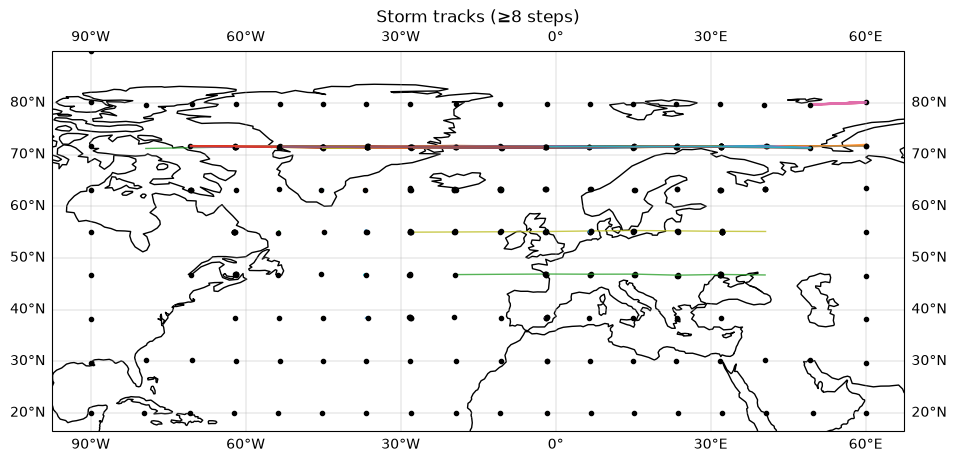

In [8]:
def split_at_dateline(lons, lats):
    """Insert NaNs where a track jumps across the 0/360 or ±180 seam."""
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    jumps = np.where(np.abs(np.diff(lons)) > 180)[0] + 1
    return np.insert(lons, jumps, np.nan), np.insert(lats, jumps, np.nan)

min_len = 8  # drop short-lived features

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.3)

for track in tracks:
    if len(track) < min_len:
        continue
    lons, lats = split_at_dateline(track.lons, track.lats)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), lw=1, alpha=0.8)
    ax.plot(lons[0], lats[0], "o", ms=3, color="k", transform=ccrs.PlateCarree())  # genesis point

ax.set_title(f"Storm tracks (≥{min_len} steps)")
plt.savefig("tracks_msl.png", dpi=150, bbox_inches="tight")
plt.show()